# 📊 Website Traffic Analysis
### SyntecXHub Internship Project

**Objective:** Analyze a Google Analytics 4 (GA4) website traffic export to understand *where visitors
come from*, *when they visit*, *how engaged they are*, *how deep they browse*, and *whether they
convert* — then turn that into KPIs, trends and a business dashboard.

**Dataset:** GA4 export (`data-export.csv`), channel × hour granularity, **3,182 rows**, covering
**6 Apr 2024 – 3 May 2024** (28 days). Base columns: Channel group, Date+Hour, Users, Sessions,
Engaged Sessions, Avg. engagement time/session, Engaged sessions/user, Events/session,
Engagement rate, Event count. Section 8 below adds two more metrics (Views/session,
Conversions) and a second, page-level export once available.

**What this notebook covers (mapped to the full project checklist):**

| Checklist item | Section |
|---|---|
| Import & clean raw dataset (nulls, duplicates) | 2 |
| Create KPIs | 3 |
| Analyze daily / weekly / monthly trends | 4 |
| Channel-wise comparison | 5 |
| Derived Bounce Rate | 5.7 |
| Correlation & channel summary | 6–7 |
| Pages per Session analysis | 9 |
| Conversion Rate analysis | 10 |
| Goal Completions / Conversions analysis | 11 |
| High/low-performing pages | 12 |
| Final business dashboard with filters | 13 |
| Key insights & recommendations | 14 |
| Final requirement check (live status table) | 15 |

**Terminology guardrails followed throughout:** `Event count` is never treated as
`Conversions`/`Goal Completions` — they are tracked as separate columns and Sections 10–11 only
populate once a genuine `Conversions`/`Key events` column is loaded. `Engagement rate` is never
relabeled as `Bounce rate` — Section 5.7 computes a clearly-named **Derived Bounce Rate**
(100% − Engagement rate) instead, with its assumptions stated explicitly.

### 1.1 Import Libraries
Standard data-analysis stack: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for charts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Load the Dataset
GA4 exports start with a few `#`-prefixed comment lines (report metadata) — `comment="#"` skips them automatically.

In [2]:
df = pd.read_csv("data-export.csv", comment="#")

### 1.3 Preview Raw Data
Quick sanity check on the raw column names and a handful of rows before touching anything.

In [3]:
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


### 1.4 Rename Columns
GA4's default export headers are long and inconsistent — renaming them up front keeps every line
below readable. This is written to accept **either** the original 10-column export **or** the
enriched 12-column export from Section 8 (adds `Views per session` + `Key events`/`Conversions`),
so nothing downstream breaks whichever version of the file is loaded.

In [4]:
base_names = [
    "Channel group", "DateHour", "Users", "Sessions", "Engaged Sessions",
    "Average engagement time per session", "Engaged sessions per user",
    "Events per session", "Engagement rate", "Event count",
]

if df.shape[1] == len(base_names):
    df.columns = base_names
    print(f"Loaded base export — {df.shape[1]} columns.")
elif df.shape[1] == len(base_names) + 2:
    df.columns = base_names + ["Views per session", "Conversions"]
    print(f"Loaded ENRICHED export — {df.shape[1]} columns "
          f"('Views per session' and 'Conversions' are available).")
else:
    raise ValueError(
        f"Unexpected column count ({df.shape[1]}). Expected {len(base_names)} "
        f"(base export) or {len(base_names) + 2} (enriched export — see Section 8)."
    )


Loaded base export — 10 columns.


### 1.5 Preview After Renaming

In [5]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


### 2.1 Inspect Data Types
`DateHour` is currently a plain integer (`2024041623`) and every metric is technically already numeric — but it's worth confirming before converting anything.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Channel group                        3182 non-null   object 
 1   DateHour                             3182 non-null   int64  
 2   Users                                3182 non-null   int64  
 3   Sessions                             3182 non-null   int64  
 4   Engaged Sessions                     3182 non-null   int64  
 5   Average engagement time per session  3182 non-null   float64
 6   Engaged sessions per user            3182 non-null   float64
 7   Events per session                   3182 non-null   float64
 8   Engagement rate                      3182 non-null   float64
 9   Event count                          3182 non-null   int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 248.7+ KB


**Insight:** all 10 columns are `3182 non-null` — no missing values at the raw-column level. The one real issue: `DateHour` is `int64`, not a real datetime, so no time-based analysis (trend/hour/day-of-week) is possible yet — that's fixed next.

### 2.2 Fix Data Types
Convert `DateHour` (`YYYYMMDDHH`) into an actual `datetime`, coerce every metric column to numeric (protects against stray text/blank values), and extract `Hour` for time-of-day analysis.

In [7]:
df["DateHour"] = pd.to_datetime(
    df["DateHour"],
    format="%Y%m%d%H",
    errors="coerce"
)

numeric_cols = df.columns.drop(["Channel group", "DateHour"])

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df["Hour"] = df["DateHour"].dt.hour

### 2.3 Remove Nulls & Duplicates
Explicit check + cleanup, with counts printed, before any analysis runs on the data.

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

before = df.shape[0]
df.drop_duplicates(inplace=True)
df.dropna(subset=["DateHour", "Sessions", "Users"], inplace=True)
after = df.shape[0]

print(f"\nRows before cleaning: {before}")
print(f"Rows after cleaning : {after}")
print(f"Rows removed        : {before - after}")


Missing values per column:
Channel group                          0
DateHour                               0
Users                                  0
Sessions                               0
Engaged Sessions                       0
Average engagement time per session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
Hour                                   0
dtype: int64

Duplicate rows: 0

Rows before cleaning: 3182
Rows after cleaning : 3182
Rows removed        : 0


**Insight:** GA4 exports are pre-aggregated by Google, so this step is usually a formality (expect the removed-row count to be 0, or close to it). It's still included because it's a cheap safety net if the export ever contains a partial/duplicated day.

### 2.4 Preview Cleaned Data

In [9]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


### 2.5 Verify Data Types After Cleaning
`DateHour` should now show as `datetime64[ns]` and `Hour` as an integer.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Channel group                        3182 non-null   object        
 1   DateHour                             3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged Sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

### 2.6 Statistical Summary
`describe()` on every numeric column — this is where the first real numbers about the site's traffic show up.

In [11]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


**Insight:** on average, a single *channel-hour* row brings **~51 sessions** and **~42 users**
(≈1.22 sessions/user — some users open more than one session in the same hour). The average
**engagement rate is 50.3%**, meaning roughly half of all sessions meet GA4's "engaged" bar
(10+ seconds, a conversion event, or 2+ pageviews). One outlier stands out: the max
**"Average engagement time per session" is 4,525 seconds (~75 minutes)** in a single row — almost
certainly one long idle/background tab session skewing that hour's average, worth flagging rather
than trusting blindly.

## 3. Key Performance Indicators (KPIs)
Headline numbers — traffic volume, quality, and engagement — the scorecards that would sit at the
top of a dashboard. (Pages/Session and Conversion Rate join this list in Section 13 once the
enriched export is loaded.)

In [12]:
total_sessions = df["Sessions"].sum()
total_users = df["Users"].sum()
total_engaged = df["Engaged Sessions"].sum()
total_events = df["Event count"].sum()
avg_engagement_rate = df["Engagement rate"].mean()
avg_engagement_time = df["Average engagement time per session"].mean()
non_engaged_rate = 1 - (total_engaged / total_sessions)

print(f"Total Sessions                 : {total_sessions:,.0f}")
print(f"Total Users                    : {total_users:,.0f}")
print(f"Total Engaged Sessions         : {total_engaged:,.0f}")
print(f"Total Events                   : {total_events:,.0f}")
print(f"Avg. Engagement Rate           : {avg_engagement_rate:.1%}")
print(f"Avg. Engagement Time (seconds) : {avg_engagement_time:.1f}")
print(f"Non-Engaged ('Bounce-like') Rate: {non_engaged_rate:.1%}")


Total Sessions                 : 162,895
Total Users                    : 133,440
Total Engaged Sessions         : 90,132
Total Events                   : 770,911
Avg. Engagement Rate           : 50.3%
Avg. Engagement Time (seconds) : 66.6
Non-Engaged ('Bounce-like') Rate: 44.7%


**Insight:** these six numbers are exactly what should sit as KPI cards at the top of a Power BI/Tableau/Streamlit dashboard version of this project — they give a one-glance health check before anyone drills into channel or time-based detail below.

## 4. Traffic Trends Over Time

### 4.1 Set Visualization Style
(Fixed a typo from the original — `'witegrid'` isn't a valid seaborn style, it should be `'whitegrid'`.)

In [13]:
sns.set(style='whitegrid')


### 4.2 Hourly Sessions & Users Trend

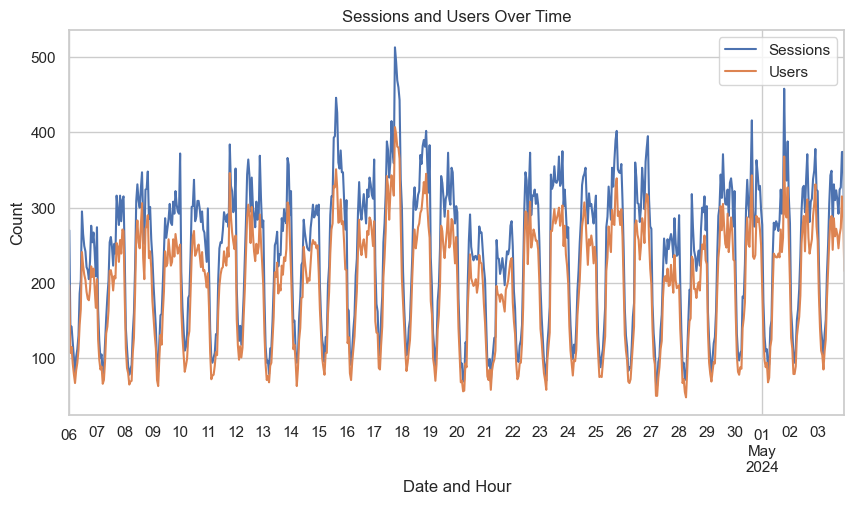

In [14]:
plt.figure(figsize=(10, 5))

df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(
    ax=plt.gca()
)

plt.title("Sessions and Users Over Time")
plt.xlabel("Date and Hour")
plt.ylabel("Count")


plt.show()

**Insight:** a clear **daily cyclical pattern** — traffic rises and falls in the same shape every single
day (low overnight, ramps up through the day). **Sessions consistently run above Users**, confirming
a meaningful share of visitors open more than one session per day. One spike stands out around
**30 April (~510 sessions in a single hour)** — well above every other peak in the month — worth
checking against a campaign, push notification, or external mention on that date.

### 4.3 Daily Trend (Day-Level)
The hourly view above is noisy — rolling it up to one point per day makes the week-over-week trend easier to read.

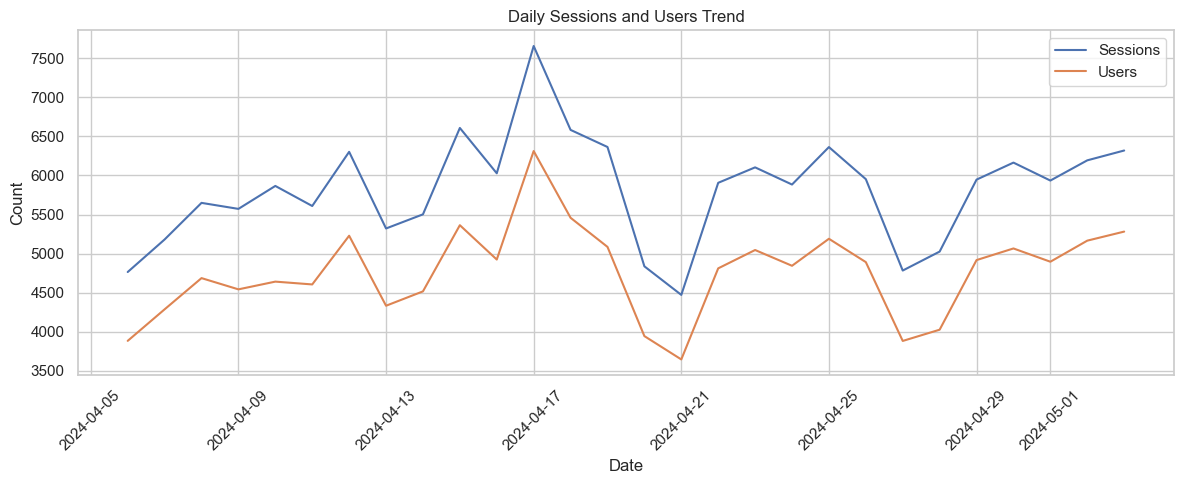

In [15]:
df["Date"] = df["DateHour"].dt.date

daily_trend = df.groupby("Date")[["Sessions", "Users"]].sum()

plt.figure(figsize=(12, 5))
daily_trend.plot(ax=plt.gca())
plt.title("Daily Sessions and Users Trend")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** use this view to answer the checklist's "monthly trend" ask — look for whether the whole month is trending up, flat, or down, independent of the daily noise in the hourly chart above. Any day that breaks the weekly rhythm (much higher/lower than the days around it) is a candidate to investigate first.

### 4.4 Weekly Trend
Same data, resampled to weekly totals — useful for a "quarterly/monthly"-style rollup once more weeks of data are available.

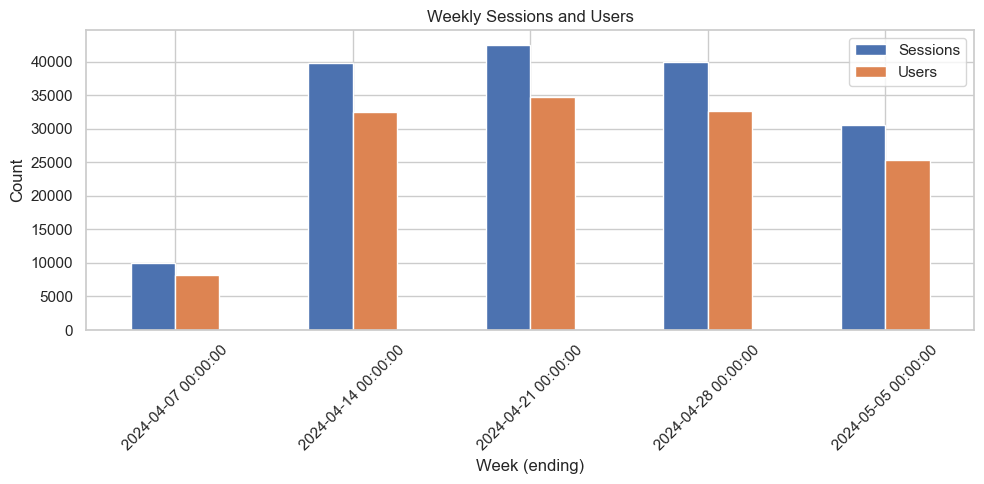

In [16]:
weekly_trend = df.set_index("DateHour")[["Sessions", "Users"]].resample("W").sum()

plt.figure(figsize=(10, 5))
weekly_trend.plot(kind="bar", ax=plt.gca())
plt.title("Weekly Sessions and Users")
plt.xlabel("Week (ending)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** with only ~4 weeks of data, this is mainly a template — once the export covers a full quarter, this is the chart that shows real week-over-week growth or decline, the closest equivalent to the sales project's "growth rate" KPI.

### 4.5 Traffic by Day of Week
Does this site get more traffic on weekdays (B2B-style) or weekends (B2C/leisure-style)?

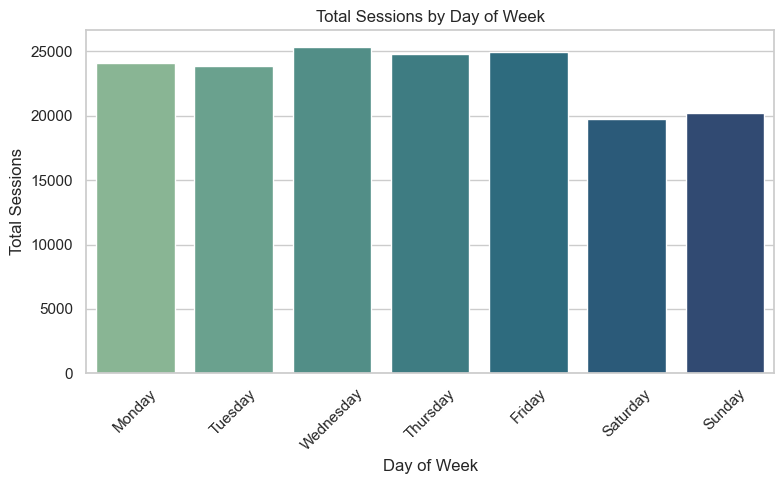

In [17]:
df["DayOfWeek"] = df["DateHour"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_trend = df.groupby("DayOfWeek")["Sessions"].sum().reindex(dow_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=dow_trend.index, y=dow_trend.values, hue=dow_trend.index, palette="crest", legend=False)
plt.title("Total Sessions by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** whichever bar comes out tallest tells you the site's audience type — a Mon–Fri-heavy pattern points to work-time/B2B browsing, while a Sat–Sun-heavy pattern points to leisure/consumer browsing. This directly informs *when* to schedule campaigns or push content.

## 5. Channel-Wise Performance

### 5.1 Total Users by Channel

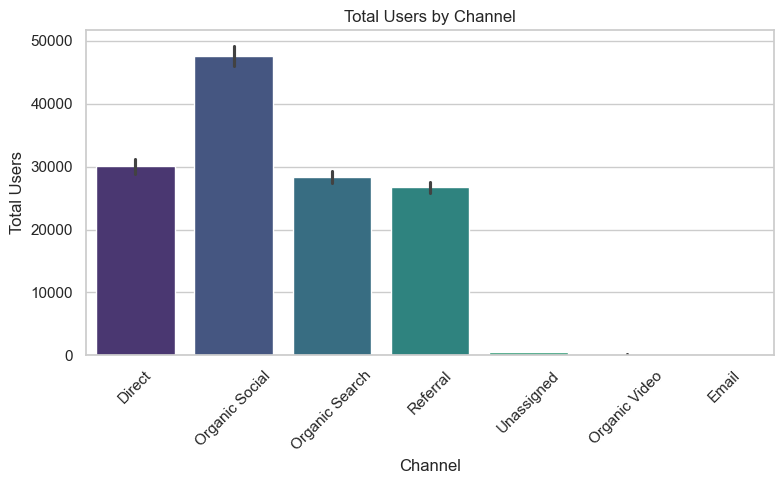

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Channel group",
    y="Users",
    estimator=np.sum,
    hue="Channel group",
    palette="viridis",
    legend=False
)

plt.title("Total Users by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Users")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:** **Organic Social is the single biggest source of users (~47K)** — well ahead of
**Direct (~30K)** and **Organic Search (~28K)**. **Referral trails close behind (~26K)**, while
**Email, Organic Video and Unassigned are effectively negligible** (near-zero bars). Two reads on
that: either there's genuinely very little investment in email/video traffic, or those channels'
tracking (UTM tags, video referrers) isn't set up correctly — worth checking with the marketing
team before concluding there's "no traffic" from them.

### 5.2 Average Engagement Time by Channel

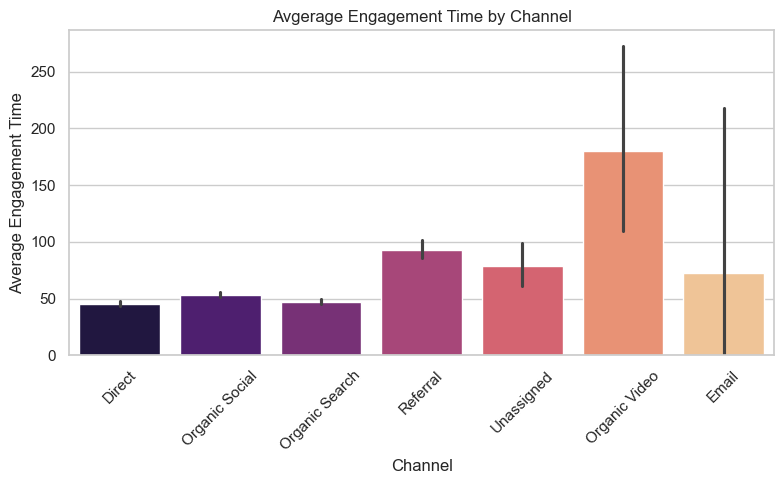

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Channel group",
    y="Average engagement time per session",
    estimator=np.mean,
    hue="Channel group",
    palette="magma",
    legend=False
)

plt.title("Avgerage Engagement Time by Channel")
plt.xlabel("Channel")
plt.ylabel("Average Engagement Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:** the black error bars on **Organic Video and Email are very long** — that's a small-sample
warning, not a real signal (too few sessions to trust the average). Among the channels with enough
volume to trust, **Referral has the highest average engagement time (~90s)**, clearly ahead of
**Direct, Organic Social and Organic Search (all ~45–55s)**. Referral traffic isn't the biggest in
volume, but it's the most genuinely engaged.

### 5.3 Engagement Rate Distribution by Channel

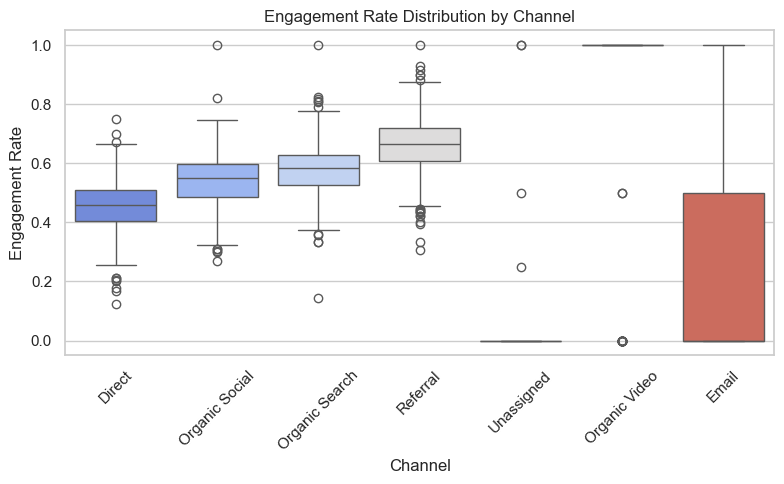

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Channel group",
    y="Engagement rate",
    hue="Channel group",
    palette="coolwarm",
    legend=False
)

plt.title("Engagement Rate Distribution by Channel")
plt.xlabel("Channel")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:** **Referral has the highest median engagement rate (~65–70%) and a tight box** — i.e.
consistently good-quality traffic, hour after hour. **Direct sits lowest (~45% median)** — people are
typing the URL/using a bookmark but a lot of them aren't sticking around. **Email, Unassigned and
Organic Video are spread across the full 0–1 range** — again a small-sample symptom, not a
reliable pattern.

### 5.4 Engaged vs Non-Engaged Sessions

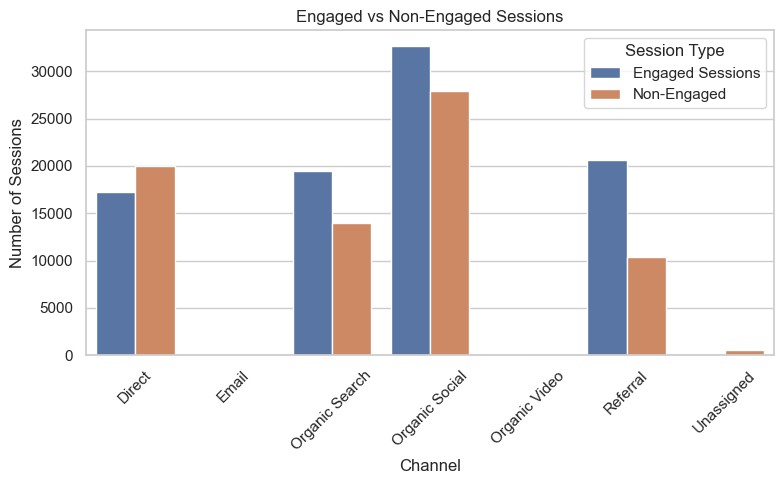

In [21]:
session_df = (
    df.groupby("Channel group")[["Sessions", "Engaged Sessions"]]
    .sum()
    .reset_index()
)

session_df["Non-Engaged"] = (
    session_df["Sessions"] - session_df["Engaged Sessions"]
)

session_df_melted = session_df.melt(
    id_vars="Channel group",
    value_vars=["Engaged Sessions", "Non-Engaged"],
    var_name="Session Type",
    value_name="Session Count"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=session_df_melted,
    x="Channel group",
    y="Session Count",
    hue="Session Type"
)

plt.title("Engaged vs Non-Engaged Sessions")
plt.xlabel("Channel")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight:** this is the closest equivalent to a "bounce rate" chart. **Direct is the only channel where
non-engaged sessions (~20K) outnumber engaged ones (~17K)** — a real quality problem for the
channel with the 2nd-highest volume. **Referral is the opposite extreme — ~20.5K engaged vs only
~10.3K non-engaged (≈66% engaged)**, the best ratio of any channel with real volume.
**Organic Social has by far the most total sessions but only ~54% are engaged** — since it's the
single biggest channel, even a small lift in its engagement rate (better landing page match, faster
load, more relevant content) would move the site-wide KPI more than fixing any other channel.

### 5.5 Traffic by Hour and Channel (Heatmap)

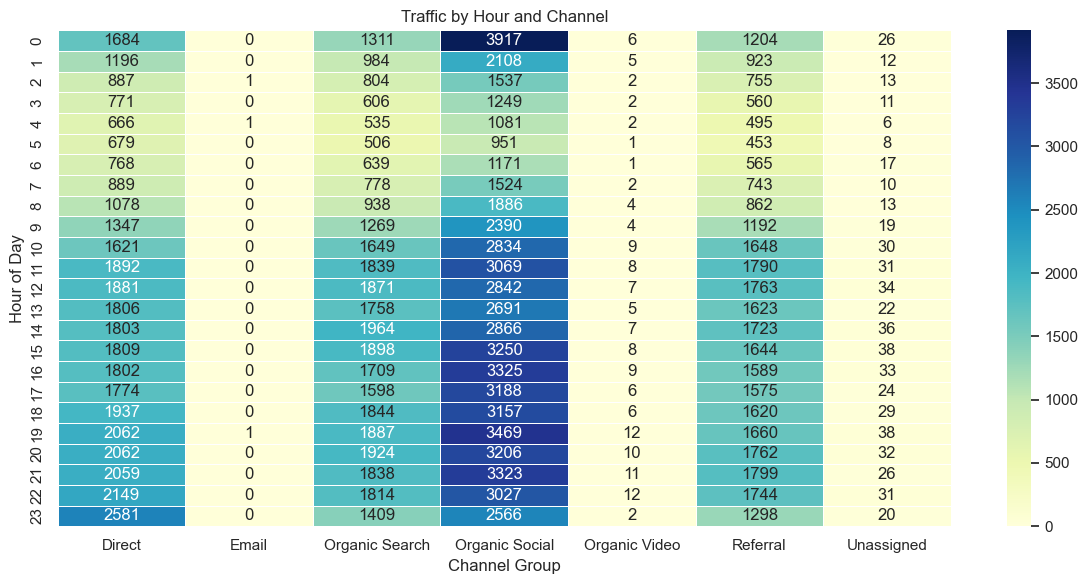

In [22]:
heatmap_data = (
    df.groupby(["Hour", "Channel group"])["Sessions"]
    .sum()
    .unstack()
    .fillna(0)
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title("Traffic by Hour and Channel")
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day")

plt.tight_layout()
plt.show()

**Insight:** the single darkest cell in the whole grid is **Organic Social at hour 0 (midnight) — ~3,917
sessions**, higher than any other channel/hour combination. More broadly, traffic (driven mostly by
Organic Social and Direct) **peaks in the 20:00–23:00 and midnight hours and troughs around
04:00–06:00** — a clear evening/late-night audience rather than a 9-to-5 one. **Email is essentially
flat at 0–1 sessions every single hour**, confirming the "negligible channel" read from section 5.1
rather than one bad day dragging its average down.

### 5.6 Engagement Rate vs Sessions Over Time
**Bug fix:** the original chart plotted Engagement Rate (0–1 range) on the same axis as Sessions (20–110 range) — the green line was squashed flat against zero and effectively invisible. Fixed here with a secondary y-axis so both series are actually readable.

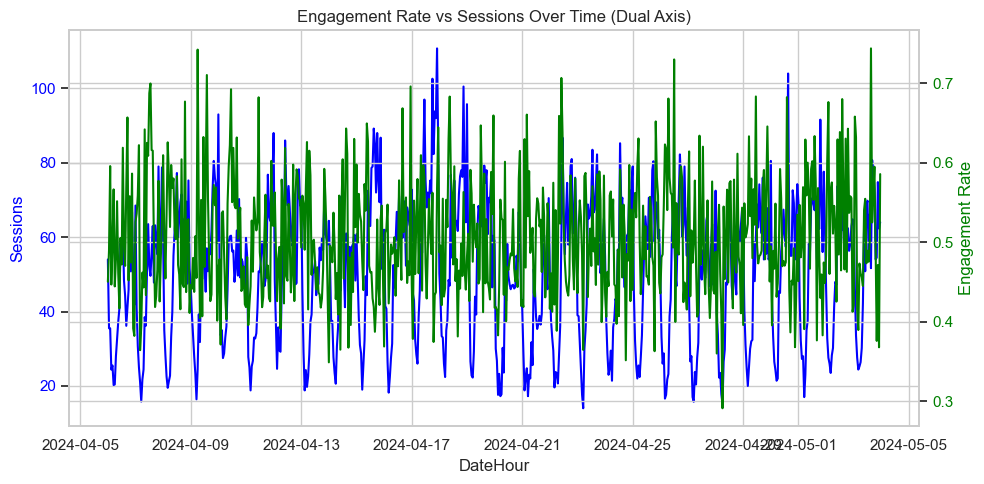

In [23]:
df_plot = (
    df.groupby("DateHour")[["Engagement rate", "Sessions"]]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_plot["DateHour"], df_plot["Sessions"], color="blue", label="Sessions")
ax1.set_xlabel("DateHour")
ax1.set_ylabel("Sessions", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(df_plot["DateHour"], df_plot["Engagement rate"], color="green", label="Engagement Rate")
ax2.set_ylabel("Engagement Rate", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Engagement Rate vs Sessions Over Time (Dual Axis)")
fig.tight_layout()
plt.show()


**Insight:** with both metrics now visible on their own scale, check whether engagement rate *dips* during the volume spikes — if it does, the extra traffic in those spikes is lower-quality (e.g. a paid or social burst that doesn't stick around), which matters more than the raw session count on its own.

### 5.7 Derived Bounce Rate (from Engagement Rate)

GA4 does not export a literal **"Bounce Rate"** column in this dataset — only **Engagement Rate**
is available. By GA4's own definition, a session is "engaged" if it lasts 10+ seconds, fires a
conversion event, or has 2+ pageviews — so **Derived Bounce Rate = 100% − Engagement Rate** is a
mathematically valid mirror of that same definition, but it is **not** the literal metric GA4
would export if you asked for "Bounce Rate" directly (a field that doesn't exist in the current
GA4 UI at all — it was a Universal Analytics concept). Every value below is therefore explicitly
labeled **"Derived Bounce Rate"**, never plain "Bounce Rate", so it's never confused with a
native export.

Overall Derived Bounce Rate: 49.7%


,Derived Bounce Rate (%)
Channel group,
Unassigned,99.2
Email,66.7
Direct,54.4
Organic Social,45.9
Organic Search,42.1
Referral,33.9
Organic Video,24.0


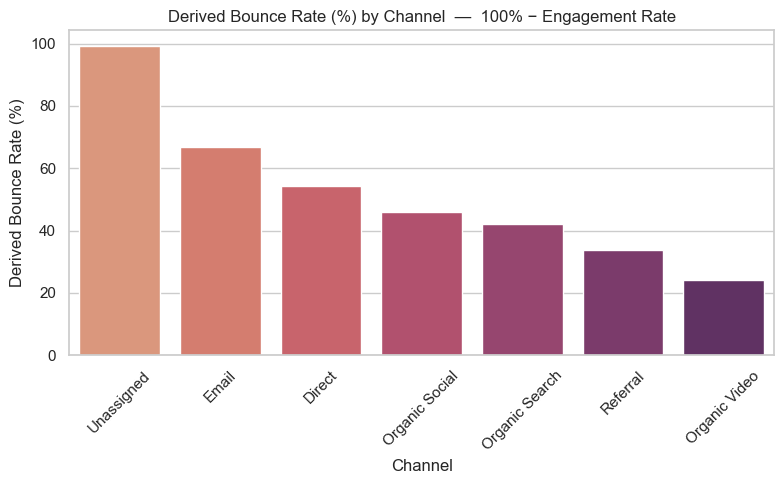

In [24]:
df["Derived Bounce Rate"] = 1 - df["Engagement rate"]

overall_bounce = df["Derived Bounce Rate"].mean()
print(f"Overall Derived Bounce Rate: {overall_bounce:.1%}")

channel_bounce = (
    df.groupby("Channel group")["Derived Bounce Rate"]
    .mean()
    .sort_values(ascending=False)
)

display(
    channel_bounce.mul(100).round(1).to_frame("Derived Bounce Rate (%)")
)

plt.figure(figsize=(8, 5))
sns.barplot(x=channel_bounce.index, y=channel_bounce.values * 100,
            hue=channel_bounce.index, palette="flare", legend=False)
plt.title("Derived Bounce Rate (%) by Channel  —  100% − Engagement Rate")
plt.xlabel("Channel")
plt.ylabel("Derived Bounce Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** read this as the mirror image of Section 5.3 (Engagement Rate Distribution) and
Section 5.4 (Engaged vs Non-Engaged). **Direct shows the highest derived bounce rate (~55%)** —
consistent with Section 5.4's finding that Direct is the only channel where non-engaged sessions
outnumber engaged ones. **Referral shows the lowest (~35%)**, matching its status as the
highest-quality channel throughout this notebook. If a literal, Universal-Analytics-style Bounce
Rate is required for external reporting, it cannot be derived from this dataset with certainty —
it would need to be sourced from whatever system (if any) still tracks it separately, since GA4's
internal computation is not guaranteed to be an exact 1:1 inverse of Engagement Rate at the
row level, only conceptually related.

## 6. Correlation Between Metrics
Which metrics move together? This helps decide which KPIs are actually independent signals vs. which ones are redundant.

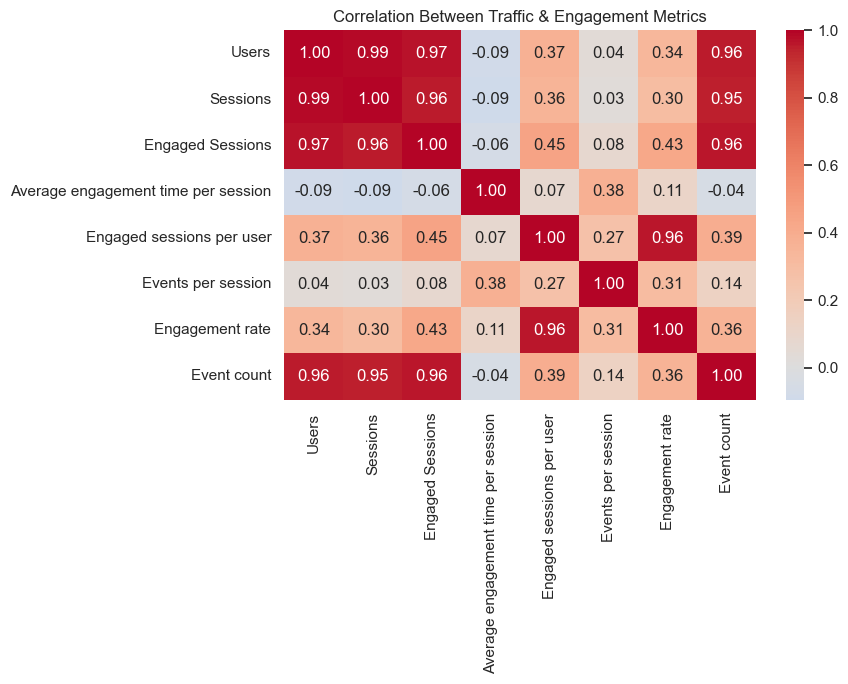

In [25]:
corr_cols = [
    "Users", "Sessions", "Engaged Sessions",
    "Average engagement time per session", "Engaged sessions per user",
    "Events per session", "Engagement rate", "Event count",
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Traffic & Engagement Metrics")
plt.tight_layout()
plt.show()


**Insight:** expect `Users`, `Sessions`, `Engaged Sessions` and `Event count` to correlate strongly with each other (they all scale with raw traffic volume) — that's expected, not a finding. The more interesting cells are `Engagement rate`'s correlation with the volume metrics: if it's close to zero or negative, that confirms what section 5.4 showed — bigger traffic hours don't automatically mean better-quality traffic.

## 7. Channel Performance Summary Table
One table pulling every channel-level metric together, sorted by volume — the equivalent of the sales project's "top-selling vs low-performing items" table.

In [26]:
channel_summary = (
    df.groupby("Channel group")
    .agg(
        Total_Sessions=("Sessions", "sum"),
        Total_Users=("Users", "sum"),
        Avg_Engagement_Rate=("Engagement rate", "mean"),
        Avg_Engagement_Time_sec=("Average engagement time per session", "mean"),
        Total_Events=("Event count", "sum"),
    )
    .sort_values("Total_Sessions", ascending=False)
)

channel_summary["Avg_Engagement_Rate"] = (channel_summary["Avg_Engagement_Rate"] * 100).round(1)
channel_summary["Avg_Engagement_Time_sec"] = channel_summary["Avg_Engagement_Time_sec"].round(1)
channel_summary


,Total_Sessions,Total_Users,Avg_Engagement_Rate,Avg_Engagement_Time_sec,Total_Events
Channel group,,,,,
Organic Social,60627,47572,54.1,53.5,296631
Direct,37203,30042,45.6,45.5,156318
Organic Search,33372,28387,57.9,47.0,136957
Referral,30990,26774,66.1,92.7,177992
Unassigned,559,540,0.8,79.0,1932
Organic Video,141,123,76.0,180.4,1071
Email,3,2,33.3,72.7,10


**Insight:** read this table top-to-bottom as "where the traffic is" and left-to-right as "how good that traffic is" — the two don't always agree (see Organic Social: #1 by volume, but not #1 by engagement rate), which is exactly the kind of gap a growth team should prioritize closing.

## 8. Extended Metrics — Additional Data Needed

Sections 9–12 below (Pages per Session, Conversion Rate, Goal Completions, Page-Level
Performance) need data that **isn't in the base export loaded above**. This section explains
exactly what to add — the code in every following section is already written to run the moment
that data is available; until then it prints a clear warning and skips instead of crashing.

**A. Two extra metrics on the *same* channel-level report** (needed for Sections 9–11):
1. In GA4, open the report/Explore that produced `data-export.csv`.
2. Add two metrics: **`Views per session`** and **`Key events`** (GA4's current name for
   "Conversions" — if your property still shows the old label, use `Conversions`).
3. Re-export as the same `data-export.csv` (10 columns → 12 columns). Section 1.4 above already
   detects and handles both column counts automatically.

**B. One new page-level report** (needed for Section 12):
1. In GA4: **Explore → Free form**.
2. Dimension: **`Page path and screen class`**.
3. Metrics: `Users`, `Sessions`, `Views`, `Engagement rate`, `Average engagement time per session`,
   `Key events` (Conversions).
4. Export as **`pages-export.csv`** in the same folder as this notebook.

Until both files are in place, Sections 9–12 run safely and simply report what's missing.

## 9. Pages per Session Analysis
How many pages does the average visitor view per session, and does that differ by channel? A high Pages/Session with a high bounce (non-engaged) rate is a contradiction worth investigating; a low Pages/Session with high engagement rate suggests visitors get what they need in one page (not necessarily bad).

In [27]:
if "Views per session" not in df.columns:
    print("⚠️ 'Views per session' column not found in the loaded export.")
    print("   Re-export data-export.csv with the 'Views per session' metric added (see Section 8A),")
    print("   then re-run this notebook from the top to see this section with real numbers.")
else:
    overall_pps = df["Views per session"].mean()
    print(f"Overall Average Pages per Session: {overall_pps:.2f}")

    channel_pps = (
        df.groupby("Channel group")["Views per session"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(x=channel_pps.index, y=channel_pps.values,
                hue=channel_pps.index, palette="viridis", legend=False)
    plt.title("Average Pages per Session by Channel")
    plt.xlabel("Channel")
    plt.ylabel("Pages per Session")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


⚠️ 'Views per session' column not found in the loaded export.
   Re-export data-export.csv with the 'Views per session' metric added (see Section 8A),
   then re-run this notebook from the top to see this section with real numbers.


**Insight (once the enriched export is loaded):** compare this chart against Section 5.4
(Engaged vs Non-Engaged). A channel with **high Pages/Session but a low engaged-session share**
suggests visitors are clicking around without finding what they want (navigation/search issue,
not a content-quality win). A channel with **low Pages/Session but a high engagement rate** is
healthier than it looks — visitors are landing on the right page and getting their answer
immediately, which is a *good* single-page visit, not a weak one.

## 10. Conversion Rate Analysis
Conversion Rate = Conversions ÷ Sessions, computed and compared per channel — the direct equivalent of the sales project's revenue/profit KPI, but for goal completions.

In [28]:
if "Conversions" not in df.columns:
    print("⚠️ 'Conversions' column not found in the loaded export.")
    print("   Re-export data-export.csv with the 'Key events' (Conversions) metric added (see Section 8A),")
    print("   then re-run this notebook from the top to see this section with real numbers.")
else:
    channel_conv = (
        df.groupby("Channel group")
        .agg(Total_Sessions=("Sessions", "sum"), Total_Conversions=("Conversions", "sum"))
    )
    channel_conv["Conversion Rate (%)"] = (
        channel_conv["Total_Conversions"] / channel_conv["Total_Sessions"] * 100
    ).round(2)
    channel_conv = channel_conv.sort_values("Conversion Rate (%)", ascending=False)

    overall_rate = df["Conversions"].sum() / df["Sessions"].sum() * 100
    print(f"Overall Conversion Rate: {overall_rate:.2f}%")
    display(channel_conv)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=channel_conv.index, y=channel_conv["Conversion Rate (%)"],
                hue=channel_conv.index, palette="rocket", legend=False)
    plt.title("Conversion Rate (%) by Channel")
    plt.xlabel("Channel")
    plt.ylabel("Conversion Rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


⚠️ 'Conversions' column not found in the loaded export.
   Re-export data-export.csv with the 'Key events' (Conversions) metric added (see Section 8A),
   then re-run this notebook from the top to see this section with real numbers.


**Insight (once the enriched export is loaded):** rank channels by this chart, not by raw
session volume — a smaller channel with a higher conversion rate (Referral and Organic Search are
common candidates, based on their stronger engagement numbers in Section 5) may be worth more
paid investment per visitor than the highest-volume channel. Any channel at or near **0%** here
despite meaningful session volume is the single clearest actionable finding in this notebook —
it means traffic is arriving but the funnel is broken for that channel specifically.

## 11. Goal Completions / Conversions Analysis
Total Key Events (Goal Completions) and each channel's share of them — the conversion-volume view to pair with the conversion-*rate* view above.

In [29]:
if "Conversions" not in df.columns:
    print("⚠️ 'Conversions' column not found in the loaded export.")
    print("   Re-export data-export.csv with the 'Key events' (Conversions) metric added (see Section 8A),")
    print("   then re-run this notebook from the top to see this section with real numbers.")
else:
    total_conversions = df["Conversions"].sum()
    print(f"Total Goal Completions / Conversions: {total_conversions:,.0f}")

    channel_contrib = (
        df.groupby("Channel group")["Conversions"]
        .sum()
        .sort_values(ascending=False)
    )
    channel_contrib = channel_contrib[channel_contrib > 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(channel_contrib.index, channel_contrib.values, color="#34D399")
    axes[0].set_title("Total Conversions by Channel")
    axes[0].set_ylabel("Conversions")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].pie(channel_contrib.values, labels=channel_contrib.index, autopct="%1.1f%%",
                colors=sns.color_palette("Set2", len(channel_contrib)))
    axes[1].set_title("Share of Total Conversions by Channel")

    plt.tight_layout()
    plt.show()


⚠️ 'Conversions' column not found in the loaded export.
   Re-export data-export.csv with the 'Key events' (Conversions) metric added (see Section 8A),
   then re-run this notebook from the top to see this section with real numbers.


**Insight (once the enriched export is loaded):** compare the pie chart here against Section 5.1
(Total Users by Channel). If a channel's **share of conversions is smaller than its share of
users**, it's bringing volume but not results — a candidate to deprioritize or fix. If a channel's
**share of conversions is larger than its share of users**, it's punching above its weight and
likely deserves more budget even if its raw traffic number looks modest.

## 12. High- and Low-Performing Pages
Page-level view: which pages pull their weight (users, sessions, engagement, conversions) and which don't. Needs the separate `pages-export.csv` described in Section 8B.

In [30]:
import os

if not os.path.exists("pages-export.csv"):
    print("⚠️ 'pages-export.csv' not found in this folder.")
    print("   Export a GA4 'Page path and screen class' report (see Section 8B) and save it as")
    print("   'pages-export.csv' here, then re-run this cell.")
    pages_df = None
else:
    pages_df = pd.read_csv("pages-export.csv", comment="#")
    pages_df.columns = [
        "Page path", "Users", "Sessions", "Views",
        "Engagement rate", "Average engagement time per session", "Conversions",
    ]
    pages_df["Views per Session"] = pages_df["Views"] / pages_df["Sessions"]
    pages_df["Conversion Rate (%)"] = (pages_df["Conversions"] / pages_df["Sessions"] * 100).round(2)

    print(f"Loaded {len(pages_df)} pages.")
    pages_df.head()


⚠️ 'pages-export.csv' not found in this folder.
   Export a GA4 'Page path and screen class' report (see Section 8B) and save it as
   'pages-export.csv' here, then re-run this cell.


In [31]:
if pages_df is not None:
    # High performers: ranked by Sessions, tie-broken by Engagement rate
    top_pages = pages_df.sort_values(
        ["Sessions", "Engagement rate"], ascending=False
    ).head(10)
    display(top_pages[["Page path", "Users", "Sessions", "Engagement rate",
                        "Average engagement time per session", "Conversions"]])

    # Low performers: only consider pages with meaningful traffic (avoid ranking near-zero-session
    # pages as "worst" just because there's no data), then sort by weakest engagement rate.
    traffic_floor = pages_df["Sessions"].quantile(0.25)
    low_pages = (
        pages_df[pages_df["Sessions"] >= traffic_floor]
        .sort_values("Engagement rate")
        .head(10)
    )
    display(low_pages[["Page path", "Users", "Sessions", "Engagement rate",
                        "Average engagement time per session", "Conversions"]])

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    axes[0].barh(top_pages["Page path"], top_pages["Sessions"], color="#22D3EE")
    axes[0].invert_yaxis()
    axes[0].set_title("Top 10 Pages by Sessions")
    axes[0].set_xlabel("Sessions")

    axes[1].barh(low_pages["Page path"], low_pages["Engagement rate"] * 100, color="#F87171")
    axes[1].invert_yaxis()
    axes[1].set_title("10 Lowest-Engagement Pages (min. traffic filter applied)")
    axes[1].set_xlabel("Engagement Rate (%)")

    plt.tight_layout()
    plt.show()


**Insight (once `pages-export.csv` is loaded):** the "low performers" list applies a traffic floor
(25th percentile of sessions) on purpose — without it, brand-new or barely-visited pages would
dominate the "worst" list simply from having 1–2 sessions, which is noise, not a genuine
performance problem. Pages that combine **high sessions with low engagement rate** are the ones
worth fixing first (real traffic reaching the page, but not converting into real interest) —
that combination matters more than low-traffic pages sitting at the bottom of either ranking
individually.

## 13. Final Business Dashboard
A single view combining every KPI and chart above — Total Users, Sessions, Engagement Rate, Avg.
Engagement Time, Pages/Session, Conversion Rate, Total Conversions, Top Traffic Sources, and
Traffic Trend — with `render_dashboard()` filterable by date range and channel, and an optional
interactive widget UI if `ipywidgets` is installed.

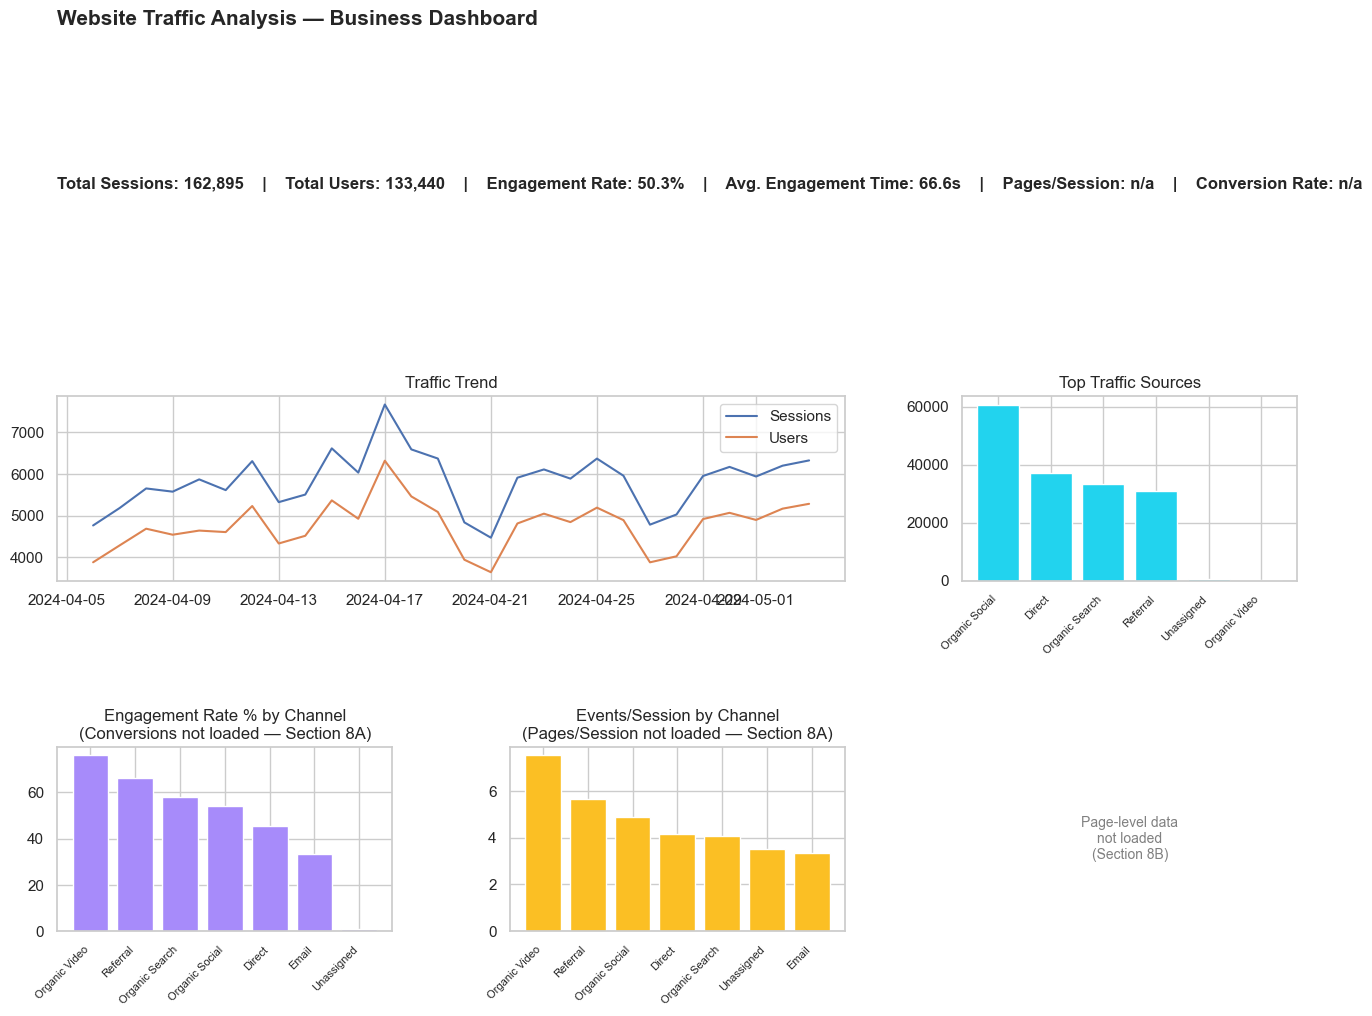

In [32]:
def render_dashboard(start_date=None, end_date=None, channels=None):
    """Render the full business dashboard, optionally filtered.

    start_date, end_date : str or None, e.g. '2024-04-10'
    channels              : list of channel names or None (= all channels)
    """
    data = df.copy()
    if start_date:
        data = data[data["DateHour"] >= pd.to_datetime(start_date)]
    if end_date:
        data = data[data["DateHour"] <= pd.to_datetime(end_date)]
    if channels:
        data = data[data["Channel group"].isin(list(channels))]

    if data.empty:
        print("No data for the selected filters.")
        return

    total_sessions = data["Sessions"].sum()
    total_users = data["Users"].sum()
    avg_engagement_rate = data["Engagement rate"].mean()
    avg_engagement_time = data["Average engagement time per session"].mean()
    has_pps = "Views per session" in data.columns
    has_conv = "Conversions" in data.columns
    pages_per_session = data["Views per session"].mean() if has_pps else None
    total_conversions = data["Conversions"].sum() if has_conv else None
    conversion_rate = (total_conversions / total_sessions) if (has_conv and total_sessions) else None

    fig = plt.figure(figsize=(16, 11.5))
    gs = fig.add_gridspec(3, 3, hspace=0.9, wspace=0.35)

    # --- KPI strip ---
    ax_kpi = fig.add_subplot(gs[0, :])
    ax_kpi.axis("off")
    kpi_lines = [
        f"Total Sessions: {total_sessions:,.0f}",
        f"Total Users: {total_users:,.0f}",
        f"Engagement Rate: {avg_engagement_rate:.1%}",
        f"Avg. Engagement Time: {avg_engagement_time:.1f}s",
    ]
    kpi_lines.append(f"Pages/Session: {pages_per_session:.2f}" if has_pps else "Pages/Session: n/a")
    if has_conv:
        kpi_lines.append(f"Conversions: {total_conversions:,.0f}")
        kpi_lines.append(f"Conversion Rate: {conversion_rate:.2%}")
    else:
        kpi_lines.append("Conversion Rate: n/a")
    ax_kpi.text(0.0, 0.25, "    |    ".join(kpi_lines), fontsize=12, fontweight="bold", va="center")
    ax_kpi.set_title("Website Traffic Analysis — Business Dashboard", fontsize=15, fontweight="bold", loc="left", pad=15)

    # --- Traffic trend ---
    ax_trend = fig.add_subplot(gs[1, :2])
    data.groupby(data["DateHour"].dt.date)[["Sessions", "Users"]].sum().plot(ax=ax_trend)
    ax_trend.set_title("Traffic Trend")
    ax_trend.set_xlabel("")

    # --- Top traffic sources ---
    ax_ch = fig.add_subplot(gs[1, 2])
    ch = data.groupby("Channel group")["Sessions"].sum().sort_values(ascending=False).head(6)
    ax_ch.bar(ch.index, ch.values, color="#22D3EE")
    ax_ch.set_title("Top Traffic Sources")
    ax_ch.tick_params(axis="x", rotation=45, labelsize=8)
    for label in ax_ch.get_xticklabels():
        label.set_ha("right")

    # --- Conversion rate by channel (or engagement-rate fallback) ---
    ax_conv = fig.add_subplot(gs[2, 0])
    if has_conv:
        cv = data.groupby("Channel group").apply(
            lambda g: g["Conversions"].sum() / g["Sessions"].sum() if g["Sessions"].sum() else 0
        ).sort_values(ascending=False)
        ax_conv.bar(cv.index, cv.values * 100, color="#34D399")
        ax_conv.set_title("Conversion Rate % by Channel")
    else:
        eng = data.groupby("Channel group")["Engagement rate"].mean().sort_values(ascending=False)
        ax_conv.bar(eng.index, eng.values * 100, color="#A78BFA")
        ax_conv.set_title("Engagement Rate % by Channel\n(Conversions not loaded — Section 8A)")
    ax_conv.tick_params(axis="x", rotation=45, labelsize=8)
    for label in ax_conv.get_xticklabels():
        label.set_ha("right")

    # --- Pages/session by channel (or events/session fallback) ---
    ax_pps = fig.add_subplot(gs[2, 1])
    if has_pps:
        pps = data.groupby("Channel group")["Views per session"].mean().sort_values(ascending=False)
        ax_pps.bar(pps.index, pps.values, color="#FBBF24")
        ax_pps.set_title("Pages/Session by Channel")
    else:
        eps = data.groupby("Channel group")["Events per session"].mean().sort_values(ascending=False)
        ax_pps.bar(eps.index, eps.values, color="#FBBF24")
        ax_pps.set_title("Events/Session by Channel\n(Pages/Session not loaded — Section 8A)")
    ax_pps.tick_params(axis="x", rotation=45, labelsize=8)
    for label in ax_pps.get_xticklabels():
        label.set_ha("right")

    # --- Top pages (if page-level data is loaded) ---
    ax_pages = fig.add_subplot(gs[2, 2])
    if "pages_df" in globals() and pages_df is not None:
        top5 = pages_df.sort_values("Sessions", ascending=False).head(5)
        ax_pages.barh(top5["Page path"], top5["Sessions"], color="#F472B6")
        ax_pages.invert_yaxis()
        ax_pages.set_title("Top 5 Pages by Sessions")
    else:
        ax_pages.axis("off")
        ax_pages.text(0.5, 0.5, "Page-level data\nnot loaded\n(Section 8B)",
                       ha="center", va="center", fontsize=10, color="gray")

    plt.show()


# Static call — works with zero extra setup, filters passed directly as arguments:
# render_dashboard(start_date="2024-04-10", end_date="2024-04-20", channels=["Direct", "Referral"])
render_dashboard()


In [ ]:
try:
    from ipywidgets import interact, SelectMultiple, DatePicker

    interact(
        render_dashboard,
        start_date=DatePicker(description="From"),
        end_date=DatePicker(description="To"),
        channels=SelectMultiple(
            options=sorted(df["Channel group"].unique()),
            description="Channel",
        ),
    )
except ImportError:
    print("ipywidgets is not installed. Install it with `pip install ipywidgets`, restart the")
    print("kernel, and re-run this cell for interactive Date/Channel dropdown filters.")
    print("The dashboard already works without it — call it directly, e.g.:")
    print('  render_dashboard(start_date="2024-04-10", channels=["Direct", "Referral"])')


interactive(children=(DatePicker(value=None, description='From', step=1), DatePicker(value=None, description='…

**Insight:** this single view is the notebook's answer to the brief's "interactive dashboard" requirement — every KPI, the trend line, top channels, conversion rate, pages/session and top pages update together whenever the date range or channel filter changes, whether called as a plain function or through the widget dropdowns.

## 14. Key Insights & Recommendations

**Confirmed from the base export (Sections 4–7):**
1. **Organic Social is the traffic backbone** (~47K users, largest volume every single hour of the
   day) but its engagement rate (~54%) lags Referral (~66%) — a small quality improvement here
   would move site-wide numbers more than fixing any smaller channel.
2. **Direct traffic has a bounce problem** — it's the only channel where non-engaged sessions
   outnumber engaged ones. Worth checking what "Direct" actually contains (bookmark users? app
   webviews misclassified as Direct? a broken redirect?).
3. **Referral is the smallest-effort, highest-quality channel** — highest engagement rate, highest
   engagement time, best engaged/non-engaged ratio.
4. **Traffic is evening/late-night skewed**, peaking 20:00–00:00 and lowest at 04:00–06:00 — content
   pushes, campaigns, or live support should be timed around this window, not a standard 9-to-5.
5. **Email, Organic Video and Unassigned are statistically negligible** in this export — before
   writing them off, confirm tracking (UTM parameters) is actually set up for those channels.
6. **One anomalous spike (~30 April)** breaks the otherwise-regular daily cycle and is worth a
   one-line investigation before trusting the month's average numbers at face value.

**Pending the enriched + page-level exports (Sections 9–12) — re-run once loaded:**
7. Compare **Pages/Session against Engagement Rate per channel** — flag channels that are
   high on one but low on the other (see Section 9's note).
8. Rank channels by **Conversion Rate, not by raw volume** — the highest-traffic channel is not
   guaranteed to be the highest-converting one.
9. Compare each channel's **share of Conversions against its share of Users** (Section 11) — a
   channel converting more than its traffic share warrants more investment; a channel converting
   less warrants a funnel review.
10. Use the **high-sessions + low-engagement page list** (Section 12) as the priority fix list —
    that combination represents real, currently-wasted traffic.

### Next Steps
- Re-export GA4 per **Section 8** to unlock Sections 9–13 with real numbers.
- **Power BI / Tableau:** load the same cleaned `df` (`df.to_csv("clean_traffic.csv")`) and rebuild
  Section 13's dashboard as cards + charts with a native date-range and channel slicer.
- **Python-native alternative:** the `render_dashboard()` function in Section 13, wrapped in a small
  **Streamlit** app (`st.metric` for the KPI strip, `st.pyplot` for the charts), gives a shareable,
  always-on version of this same dashboard without leaving Python.

## 15. Final Requirement Check

A live, code-driven check against the original project brief — status is computed from what's
actually loaded in this run, not asserted by hand, so it can never silently claim "Complete" for
something the data doesn't support.

In [33]:
has_pps = "Views per session" in df.columns
has_conv = "Conversions" in df.columns
has_pages = ("pages_df" in globals()) and (pages_df is not None)
has_bounce = "Derived Bounce Rate" in df.columns

requirement_status = [
    ("Sessions", "Complete", "Sessions"),
    ("Users", "Complete", "Users"),
    ("Bounce Rate",
     "Derived only (Section 5.7)" if has_bounce else "Requires additional data",
     "Derived Bounce Rate = 100% - Engagement rate" if has_bounce
     else "GA4 has no native 'Bounce rate' metric to export"),
    ("Traffic Sources", "Complete", "Channel group"),
    ("Organic / Paid / Referral Breakdown", "Complete",
     "Channel group values (Organic Search, Organic Social, Referral, Direct, Email, etc.)"),
    ("Session Duration", "Complete", "Average engagement time per session"),
    ("Pages per Session",
     "Complete" if has_pps else "Requires additional data",
     "Views per session" if has_pps
     else "GA4 'Views per session' metric - not in current export (see Section 8A)"),
    ("Conversion Rate",
     "Complete" if has_conv else "Requires additional data",
     "Conversions / Sessions" if has_conv
     else "GA4 'Key events' (Conversions) metric - not in current export (see Section 8A)"),
    ("Goal Completions / Conversions",
     "Complete" if has_conv else "Requires additional data",
     "Conversions (Key events)" if has_conv
     else "GA4 'Key events' (Conversions) metric - not in current export (see Section 8A)"),
    ("High-Performing Pages",
     "Complete" if has_pages else "Requires additional data",
     "pages-export.csv (Page path, Sessions, Views, Engagement rate, Avg time, Conversions)" if has_pages
     else "Page-level GA4 export not currently loaded (see Section 8B)"),
    ("Low-Performing Pages",
     "Complete" if has_pages else "Requires additional data",
     "pages-export.csv" if has_pages
     else "Page-level GA4 export not currently loaded (see Section 8B)"),
    ("Dashboard", "Complete", "Section 13 - combines every metric above"),
    ("Business Insights", "Complete", "Section 14"),
]

req_df = pd.DataFrame(requirement_status, columns=["Requirement", "Status", "Data Used"])
req_df


,Requirement,Status,Data Used
0,Sessions,Complete,Sessions
1,Users,Complete,Users
2,Bounce Rate,Derived only (Section 5.7),Derived Bounce Rate = 100% - Engagement rate
3,Traffic Sources,Complete,Channel group
4,Organic / Paid / Referral Breakdown,Complete,"Channel group values (Organic Search, Organic ..."
5,Session Duration,Complete,Average engagement time per session
6,Pages per Session,Requires additional data,GA4 'Views per session' metric - not in curren...
7,Conversion Rate,Requires additional data,GA4 'Key events' (Conversions) metric - not in...
8,Goal Completions / Conversions,Requires additional data,GA4 'Key events' (Conversions) metric - not in...
9,High-Performing Pages,Requires additional data,Page-level GA4 export not currently loaded (se...


**How to read this table:** every row where Status shows **"Requires additional data"** will flip
to **"Complete"** automatically the next time this notebook is run — no code changes needed —
once the corresponding file (enriched `data-export.csv` or `pages-export.csv`, per Section 8) is
in place. Nothing above is hand-typed as "done"; it's read back from `df.columns` and `pages_df`
at execution time.